In [1]:
%pip install matplotlib numpy pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


# The Machine Learning Landscape

## Tipos de sistemas de ML

Sistemas de machine learning podem ser classficados em 3 dimensoes diferentes... como o treino é feito (supervisionado, nao supervisionado, semi-supervisionado e auto-supervisionado), se ele pode ou nao aprender de forma incremental em tempo real (online vs batch learning) e como ele faz predicoes (armazena os dados antigos e compara o novo com todos os antigos ou se ele aprende uma aproximacao detectando padroes):

- Paradigma de aprendizado:
    - Supervisionado: Nesse tipo usamos labels/targets que sao variaveis respostas para treinar o modelo para predicao. Regressao para variaveis continuas e classificacao para variaveis categoricas. 
    - Nao supervisionado: Nesse tipo nao temos labols... usamos os dados para descobrir padroes e similiaridades entre os pontos e variaveis em tarefas como clustering e hierarquical clustering (divide os grupos varias vezes). Também podemos usar em algoritmos de visualizacao para reduzir a dimensao sem perder informacao espacial ou algoritmos de reducao de dimensionalidade que é usado para reduzir a dimensao de um dado perdendo o minimo de informacao possivel (mas perde informacao espacial). Outra tarefa é a de deteccao de anomalias em que o modelo é treinado em dados normais e identifica pontos novos fora do normal... uma outra chamada deteccao de novidades é usada para verificar se um ponto já apareceu ou nao antes no treino. (Enquanto anomalias sao coisas muito diferentes, novidades sao coisas totalmente diferentes e nunca vistas)
    - Semi-Supervisionado: É quando parte dos dados é rotulado e parte nao rotulado entao usamos algoritmos nao supervisionados como clustering para juntar pontos proximos e usados os rotulos mais frequentes para tomar decisoes. (google fotos faz isso juntando fotos da mesma pessoa na galeria ate voce ir la e rotular com nome que quiser).
    - Auto-supervisionado: Nesse metodo os dados nao tem rotulos entretando eles mesmos geram seus rotulos adicionando um ruido como apagar parte de uma imagem ou esconder parte do texto (como no treino de LLMs).
    - Aprendizado por reforco: Nesse cenário temos uma agente em um estado dentro de um ambiente em que o objetivo dele é escolher uma acao que maximize uma recompensa (cada acao muda seu estado e seu valor de recompensa ou penalidade).

- Treino:
    - Batch (offline) Learning: Metodo mais simples possivel em que treinamos o modelo com todos os dados de uma vez, avaliamos e colocamos em producao. Se chegar dados novos ou o modelos ficar depreciado (rot) vamos precisar treinar tudo novamente, ou seja, dados novos e dados antigos... O problema disso é que treinar tudo de uma vez demora e é computacionalmente caro. E se seu dataset nao couber na maquina ? e se precisarmos atualizar o modelo sempre para deixar ele atualizado ? E se o sistema precisar aprender sozinho e com poucos recursos (celulares) ?

    - Incremental (Online/Mini batch) Learning: Nesse modalidade (comum em redes neurais) nosso modelo é treinado gradativamente com pequenos conjuntos de dados chamados mini-batchs que podem ser pequenos pedacos de um conjunto maior ou ate mesmo novos dados que chegam de usuários em tempo real... usamos algoritmos como gradiente descendent para otimizar passo a passo o modelo em que cada passo é mais barato e rapido. É util para sistemas que atualizam muito rapido e que tem poucos recursos como o autocomplete dos celulares. Se o dataset nao cabe na memória podemos carregar apenas uma parte dele por vez, fazer o passo de treino e trocar por uma nova parte (isso é chamado de out-of-core learning) um grande problema desse é que novos dados podem vir com problemas (outliers, dados errados por causa de erros de hardware e etc) e se esses novos dados nao forem filtrados (usando identificacao de anomalias) isso irá afetar o modelo no proximo passo de treinamento e consequentemente reduzir sua performace (podemos usar learning rates mais baixos também para reduzir o efeito desses outliers, por outro lado learning rates altos podem levar a esquecimento catastrofico que consiste em esquecer oq aprendeu).

- Modelagem:

    - Instance-Based: Nesse categoria temos modelos que nao aprendem a aproximar uma funcao ou se otimizam de nenhuma forma. Temos modelos que levam consigo os dados de treino ou parte deles e usam eles sempre para fazer uma inferencia comparando o novo ponto com todos os outros por uma similiaridade ou distancia (como KNN). Esse tipo é simples mas lento e caro pois passa por todo dataset a cada inferencia e além disso tem que armazenar o dataset junto do modelo...

    - Model-Based: Nessa categoria otimizamos o modelo gradualmente usando os padroes ou regras dos dados de treino para que ele seja uma boa aproximacao matematica da funcao real dos dados. Definimos uma funcao de erro e ajustamos parametros com objetivo de minimizar esse erro.

- Outros interessantes: 

    - Aprendizado Federado (Federated Learning): Nessa modalidade queremos manter a privacidade do usuário intacta ou os dados sao muio sensiveis... Para isso, ao inves de pegar os dados dos usuários e treinar o modelo no meu datacenter eu irei treinar modelos descentralizados da seguinte maneira: Irei enviar um modelo base para todos os dispositivos dos usuários, cada dispositivo usa seus dados do usuário para treinar esse modelo, os parametros atualizados do modelos sao retornados para o datacenter principal e la é feito uma media de todos os pesos gerando um novo modelo base melhorado. Exemplo: O teclado do seu celular (Gboard). Ele aprende novas palavras e gírias com você sem nunca enviar suas mensagens privadas para os servidores do Google. O modelo aprende com todos, mas ninguém vê as mensagens de ninguém.

    - Aprender a Aprender (Meta Learning): Meta learning consiste em ensinar um modelo a aprender para que ele possa no futuro aprender com pouquissimos exemplos (few-shot learning), queremos otimizar os parametros base dele em varias tarefas tal que quando quisermos fazer um fine-tuning ele aprenda rapidamente a tarefa.

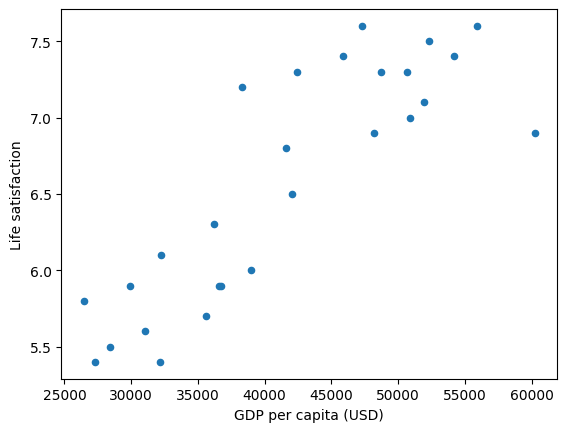

[6.01610329]
[5.73333333]


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor


data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

X = lifesat[["GDP per capita (USD)"]].values
y = lifesat["Life satisfaction"].values

lifesat.plot(kind="scatter", x="GDP per capita (USD)", y="Life satisfaction")
plt.show()

model = LinearRegression()
model2 = KNeighborsRegressor(n_neighbors=3)

# predicao para o PIB per capita de Porto Rico em 2020
X_new = [[33_442.8]] 

model.fit(X, y)
print(model.predict(X_new)) 

model2.fit(X, y)
print(model2.predict(X_new))
